# Classification — Theory and Practice

#### Block 2 of Phase 1 · ML-Notes-and-Projects

This notebook continues the study log started in `01_LinearRegression`, now moving to **classification**: predicting a categorical (here, binary) response instead of a continuous one. As before, it combines theory from *An Introduction to Statistical Learning* (ISLP, Chapter 4) with the practical approach from *Hands-On Machine Learning* (HOML).

### Dataset

We use the **UCI Heart Disease dataset** (Cleveland Clinic Foundation, 1988), a classic and well-documented dataset in clinical machine learning: 303 patients, 13 clinical predictors (age, sex, chest pain type, blood pressure, cholesterol, etc.), and a binary target indicating the pressence of heart disease.

This is a natural fit for classification (unlike `SalePrice` in Block 1, there's no meaningful continuous version of "has heart disease or not"), and the medical context makes the classification metrics we'll cover feel like real decisions rather than abstract formulas.

Dataset Source: Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). Heart Disease [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X.

### Goals of this notebook

1. Understand **why linear regression is a poor fit** for a binary response, and why it motivates a different modeling approach.
2. Implement **Logistic Regression** (first with a single predictor, then with multiple predictors), understanding the sigmoid function, log-odds, and Maximum Likelihood Estimation (MLE).
3. Learn to properly **evaluate a classifier**: confusion matrix, precision, recall, F1-score, ROC curve and AUC. Understand whyh accuracy alone can be misleading.
4. Exxplore how moving the **decision threshold** changes the precision/recall trade-off, and when that matters in practice.
5. Briefly contrast Logistin Regression with **LDA/QDA** (ISLP, Chapter 4.4), two alternative classification approaches.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_score, recall_score, f1_score, roc_curve, roc_auc_score,
    precision_recall_curve
)

sns.set_theme(style="whitegrid")
np.random.seed(42)

## 1. First Look at the Data

In [2]:
df = pd.read_csv("heart-disease.csv")
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


All 13 predictors plus the `target` column are numeric, with **no missing values**. However, several of these "numeric" columns are actually **encoded categorical variables** (e.g. `cp` = chest pain has 4 categories: 0-3; `thal` similarly). Once we reach the multiple logistic regression section, we'll treat them accordingly.

**Column reference** (from the UCI documentation):

|**Column**|**Meaning**|
|---|---|
|`age`|Age in years|
|`sex`|1 = male, 0 = female|
|`cp`|Chest pain type (0-3, categorical)|
|`trestbps`|Resting blood pressure (mm Hg)|
|`chol`|Serum cholesterol (mg/dl)|
|`fbs`|Fasting blood sugar > 120 mg/dl (1 = True)|
|`restecg`|Resting ECG results (0-2, categorical)|
|`thalach`|Maximum heart rate achieved|
|`exang`|Exersice-induced angina (1 = yes)|
|`oldpeak`|ST depression induced by exercise relative to rest|
|`slope`|Slope of the peak exercise ST segment (0-2, categorical)|
|`ca`|Number of major vessels colored by fluoroscopy (0-4)|
|`thal`|Thalassemia (0-3, categorical)|
|`target`|**1 = heart disease present, 0 = absent** (our response variable)|

In [4]:
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

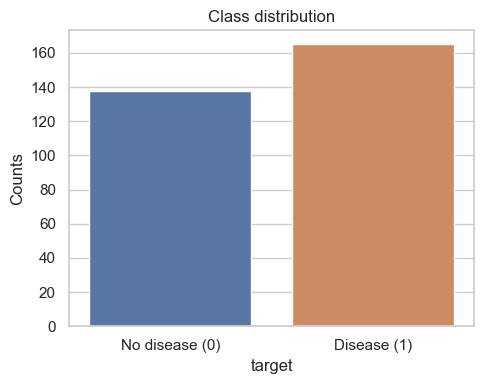

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="target", hue="target", legend=False)
plt.xticks([0,1], ["No disease (0)", "Disease (1)"])
plt.title("Class distribution")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

The classes are mildly imbalanced (165 positives vs. 138 negative, about 54%/46%), not severely enough to require special resampling techniques but enough to make it a genuinely useful example later when we discuss why accuracy alone can be a misleading metric.

## 2. Why Not Just Use Linear Regression?

Before introducing logistic regresion, it's worth seeing concretely why we need a different at all — ISLP (Chapter 4.1) motivates this well, and it's more convincing to see it rather than just being told.

Suppose we tried to predict `target` (0 or 1) directly with ordinary linear regression, using a single predictor: `thalach` (maximum heart rate achieved). Linear regression would fit a straight line through the 0/1 points and treat the output as a probability.

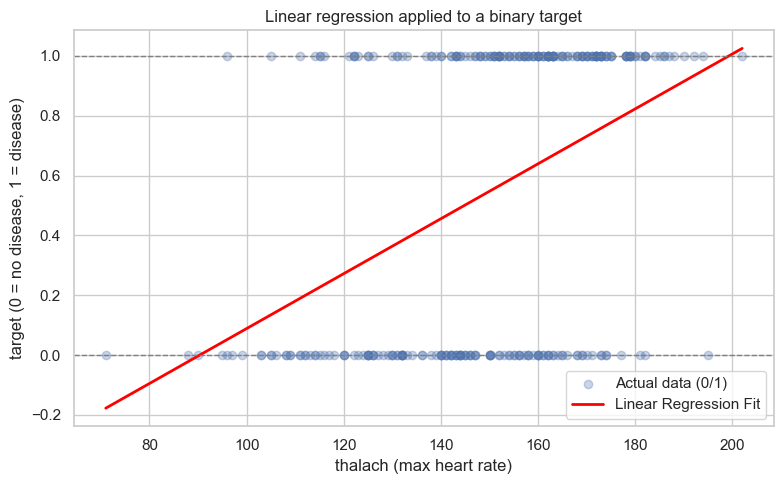

In [6]:
X_demo = df[["thalach"]].values
y_demo = df["target"].values

lin_reg_demo = LinearRegression()
lin_reg_demo.fit(X_demo, y_demo)

x_range = np.linspace(X_demo.min(), X_demo.max(), 100).reshape(-1, 1)
y_range_pred = lin_reg_demo.predict(x_range)

plt.figure(figsize=(8,5))
plt.scatter(X_demo, y_demo, alpha=0.3, label="Actual data (0/1)")
plt.plot(x_range, y_range_pred, color="red", linewidth=2, label="Linear Regression Fit")
plt.axhline(y=0, color="gray", linestyle="--", linewidth=1)
plt.axhline(y=1, color="gray", linestyle="--", linewidth=1)
plt.xlabel("thalach (max heart rate)")
plt.ylabel("target (0 = no disease, 1 = disease)")
plt.title("Linear regression applied to a binary target")
plt.legend()
plt.tight_layout()
plt.show()

Two problems are immediately visible:

1. **The predicted values are not probabilities**. For low `thalach` values, the line predicts numbers above 1; nothing stops linear regression from producing values outside the `[0,1]` range, which makes no sense as "the probability of heart disease".
2. **The relationship is forced to be a straight line**, when the actual pattern in the data is more like a threshold or S-shaped transition between two classes — for very low or very high `thalach`, we'd want the model to be confidently close to 0 or 1, not just extrapolating forever.

What we actually want is a function that takes any real-valued input and squashes it into the (0,1) range, behaving like a genuine probability. This is exactly what the sigmoid (logistic) function does, and it's the foundation of logistic regression.

## 3. Simple Logistic Regression

### 3.1 The sigmoid function

Instead of modeling $Y$ directly as a linear function of $X$, logistic regression models the **probability** that $Y$ belongs to the positive class. Writing $p(X)=P(Y=1|X)$ (ISLP, Chapter 4.3) uses the **logistic (sigmoid) function**:
$$
p(X)=\frac{e^{\beta_0+\beta_1X}}{1+e^{\beta_0+\beta_1X}}=\frac{1}{1+e^{-(\beta_0+\beta_1X)}}
$$
The key property: no matter what value $\beta_0+\beta_1X$ takes ($-\infty,+\infty$), the output always lands strictly between 0 and 1. This solves the problem we saw in Section 2.

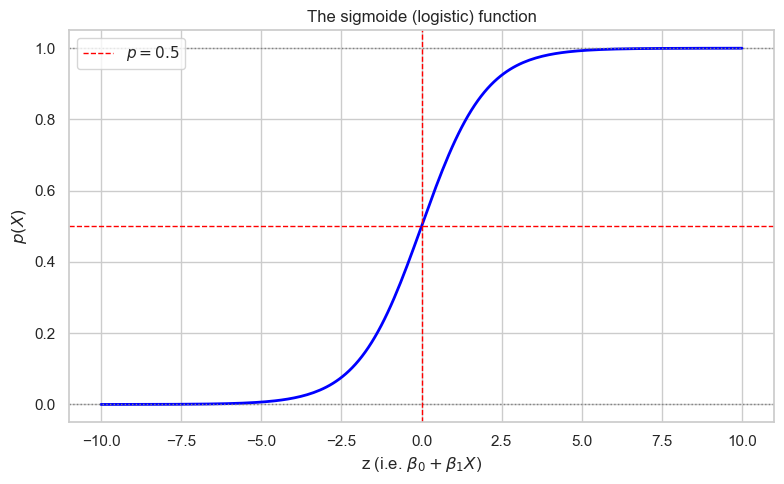

In [7]:
def sigmoid(z):
    """Maps any real number into the (0,1) interval."""
    return 1/(1+np.exp(-z))

z = np.linspace(-10, 10, 200)

plt.figure(figsize=(8,5))
plt.plot(z, sigmoid(z), linewidth=2, color='blue')
plt.axhline(y=0, color="gray", linestyle=":", linewidth=1)
plt.axhline(y=1, color="gray", linestyle=":", linewidth=1)
plt.axhline(y=0.5, color="red", linestyle="--", linewidth=1, label="$p=0.5$")
plt.axvline(x=0, color="red", linestyle="--", linewidth=1)
plt.xlabel("z (i.e. $\\beta_0+\\beta_1 X$)")
plt.ylabel("$p(X)$")
plt.title("The sigmoide (logistic) function")
plt.legend()
plt.tight_layout()
plt.show()


### 3.2 Odds and log-odds (logit)

The sigmoid formula can be rearranged into a much more interpretable form. Starting from $p(X)$ and solving for the exponential term:
$$
\frac{p(X)}{1-p(X)}=e^{-(\beta_0+\beta_1 X)}
$$

The left-hand side is called the **odds** (the ratio of the probability of the event happening to it not happening). Odds range from 0 to $\infty$: odds of 1 mean a 50/50 chance, odds of 4 mean the even is four times more likely than not.

Taking the natural logarithm of both sides gives the **log-odds (logit)**:
$$
\ln\left(\frac{p(X)}{1-p(X)}\right)=\beta_0+\beta_1 X
$$
This is the crucial insight: **logistic regression is linear, just not in $p(X)$ but in the log-odds**. 
The coefficient $\beta_1$ has a clean interpretation: a one-unit increase in $X$ increases the *log-odds* by $\beta_0$ or, equivalently, multiplies the *odds* by $e^{\beta_0}$, quantity known as **odds ratio**, and it's how logistic regression coefficients are reported in practice (especially in medicine, which fits our dataset pretty well).

### 3.3 Estimating the coefficients: Maximum Likelihood

In linear regression, we minimized the RSS and got a closed-form solution (Normal Equation). Logistic regression has no such closed form; instead, coefficients are estimated by **Maximum Likelihood Estimation (MLE)**.

The idea is basically to find the $\beta_0$, $\beta_1$ that maake the observed data most probable under the model. The likelihood functio multiplies, for each patient, the model's predicted probability of what actually happened:
$$
\ell\left(\beta_0,\beta_1\right)=\prod_{i:y_i=1}p(x_i)\prod_{i:y_i=0}\left[1-p(x_i)\right]
$$
In practice we maximize the **log-likelihood** instead (products become sums, which is far more stable numerically):
$$
\ln\ell\left(\beta_0,\beta_1\right)=\sum_{i=1}^n \left[y_i\ln p(x_i)+(1-y_i)\ln(1-p(x_i))\right]
$$
Maximizing this is equivalent to **minimizing its negative**, which is exactly the **log loss** (or binary cross-entropy) cost function used in HOML:
$$
J(\beta)=-\frac{1}{n}\sum_{i=1}^n\left[y_i\ln p(x_i)+(1-y_i)\ln(1-p(x_i))\right]
$$
Because there's no closed-form solution, this is solved numerically (typically with Gradient Descent or, in the case of `scikit-learn` and `statsmodels`, more sophisticated optimizers). Conveniently, the gradient of the log loss has the same elegant form as in linear regression:
$$
\nabla_\beta J(\beta)=\frac{1}{n}X^T\left[\sigma\left(X\beta\right)-y\right]
$$
Let's implement this from scratch to see it work.

### 3.4 Implementing logistic regression from scratch

We'll use a single predictor to start: `thalach` (maximum heart rate achieved), the same variable we used in the linear regression demo in Section 2—which makes the comparison direct.

As with Gradient Descent in Block 1, we standardize the predictor before optimizing. This matters even more here: the sigmoid saturates (its gradient approaches zero) for large $|z|$ values, so unscaled inputs can stall the optimization almost immediately.

In [8]:
X_simple = df[['thalach']].values
y_simple = df['target'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42, stratify=y_simple
)

# Standardize using training statistics only
x_mean, x_std = X_tr.mean(), X_tr.std()
X_tr_scaled = (X_tr-x_mean) / x_std
X_te_scaled = (X_te-x_mean) / x_std

# Design matrices with intercept column
X_b_tr = np.c_[np.ones((X_tr_scaled.shape[0], 1)), X_tr_scaled]
X_b_te = np.c_[np.ones((X_te_scaled.shape[0], 1)), X_te_scaled]

print(f"Train: {X_b_tr.shape[0]} | Test: {X_b_te.shape[0]}")
print(f"thalach - mean: {x_mean:.2f}, std: {x_std:.2f}")

Train: 242 | Test: 61
thalach - mean: 150.12, std: 21.93


Note the `stratify=y_simple` argument in `train_test_split`. This ensures the train and test sets preserve the same class proportions as the full dataset ($\sim 54\%$ positive). With a small dataset like this one (303 rows), a purely random split could easily end up with an unrepresentative class balance in the test set, distorting our evaluation—stratification is standard practice for classification problems.

In [9]:
def log_loss_cost(X_b, y, beta):
    """Binary cross-entropy (negative log-likelihood, averaged)."""
    p = sigmoid(X_b @ beta)
    eps = 1e-15 # avoid ln(0)
    p = np.clip(p, eps, 1-eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1-p))

def logistic_gradient_descent(X_b, y, learning_rate=0.1, n_iterations=5000):
    """Fits logistic regression by minimizing log loss via batch Gradient Descent."""
    n = len(y)
    beta = np.zeros(X_b.shape[1])
    cost_history = []

    for _ in range(n_iterations):
        p = sigmoid(X_b @ beta)
        gradient = (1 / n) * X_b.T @ (p - y)
        beta = beta - learning_rate * gradient
        cost_history.append(log_loss_cost(X_b, y, beta))

    return beta, cost_history

beta_manual, cost_history = logistic_gradient_descent(X_b_tr, y_tr)

print(f"Intercept (scaled space): {beta_manual[0]:.4f}")
print(f"Coefficient (scaled space): {beta_manual[1]:.4f}")

Intercept (scaled space): 0.1965
Coefficient (scaled space): 1.0015


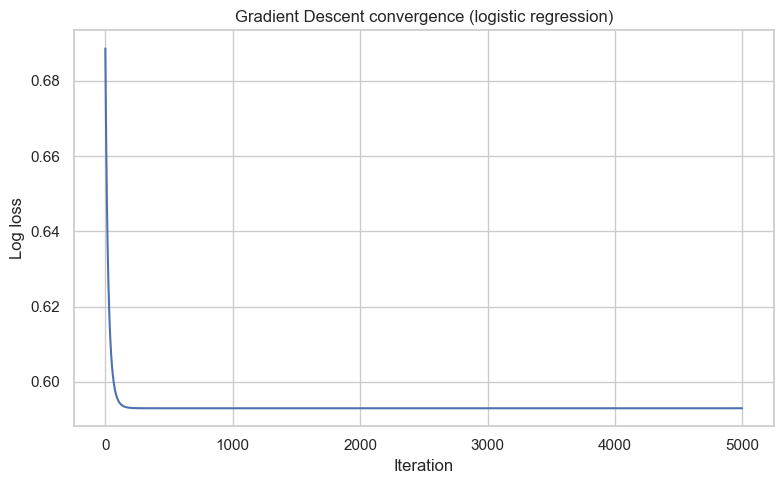

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Log loss")
plt.title("Gradient Descent convergence (logistic regression)")
plt.tight_layout()
plt.show()

### 3.5 Validating against `scikit-learn`

In [11]:
# A very large C effectively disables regularization, so sklearn performs plain MLE
log_reg_sk = LogisticRegression(C=1e12, max_iter=1000)
log_reg_sk.fit(X_tr_scaled, y_tr)

print("Comparison — from scratch vs. scikit-learn (scaled space):")
print(f"{'':15s} {'From scratch':>15s} {'scikit-learn':>15s}")
print(f"{'Intercept':15s} {beta_manual[0]:15.4f} {log_reg_sk.intercept_[0]:15.4f}")
print(f"{'Coefficient':15s} {beta_manual[1]:15.4f} {log_reg_sk.coef_[0][0]:15.4f}")

Comparison — from scratch vs. scikit-learn (scaled space):
                   From scratch    scikit-learn
Intercept                0.1965          0.1962
Coefficient              1.0015          1.0010
